# Section 0: Setup & Imports

In [1]:
# Standard Library
import os
import warnings
warnings.filterwarnings("ignore")

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Preprocessing & Utilities
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

# Imbalanced Data
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve,
                             precision_recall_curve,
                             ConfusionMatrixDisplay)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Explainability
import shap

# Model Persistence
import joblib

# Global Configuration
SEED        = 42
TEST_SIZE   = 0.20
DATA_PATH   = "/Users/vishalhooda/Downloads/ai4i2020.csv"
MODELS_DIR  = "../outputs/models/"
FIGURES_DIR = "../outputs/figures/"

# Create output directories if they don't exist
os.makedirs(MODELS_DIR, exist_ok = True)
os.makedirs(FIGURES_DIR, exist_ok = True)

# Reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot Style
plt.rcParams.update({
    "figure.figsize"    : (10, 5),
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titlesize"    : 14,
    "axes.labelsize"    : 12,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "legend.fontsize"   : 10,
    "font.family"       : "DejaVu Sans",
})

PALETTE = {
    "primary" : "#2563EB", # blue
    "danger"  : "#DC2626", # red
    "success" : "#16A34A", # green
    "warning" : "#D97706", # amber
    "neutral" : "#6B7280", # gray
    "rf"      : "#7C3AED", # violet -> Random Forest
    "xgb"     : "#EA580C", # orange -> XGBoost
    "nn"      : "#0891B2"  # cyan -> Neural Network
}

# Helper - Save Figure
def save_fig(filename: str, tight: bool = True) -> None:
    """Save the current matplotlib figure to the figures directory."""
    path = os.path.join(FIGURES_DIR, filename)
    if tight:
        plt.tight_layout()
    plt.savefig(path, bbox_inches = 'tight')
    print(f"Figure saved -> {path}")

# Helper - Print Section Banner
def section_banner(title: str) -> None:
    """Print a clearly visible section divider in notebook output."""
    bar = "=" * 60
    print(f"\n{bar}")
    print(f"  {title}")
    print(f"{bar}\n")

# Environment Verification
section_banner("Section 0 - Environment Verification")
libs = {
    "Numpy"            : np.__version__,
    "Pandas"           : pd.__version__,
    "Scikit-learn"     : __import__("sklearn").__version__,
    "XGBoost"          : __import__("xgboost").__version__,
    "Tensorflow"       : tf.__version__,
    "SHAP"             : shap.__version__,
    "imbalanced-learn" : __import__("imblearn").__version__
}

print(f"{'Library':<20} {'Version':>10}")
print("-" * 32)
for lib, ver in libs.items():
    print(f"{lib:<20} {ver:>10}")

print(f"\n  Random Seed : {SEED}")
print(f"  Test Size : {TEST_SIZE * 100:.0f}%")
print(f"  Data Path    : {DATA_PATH}")
print(f"  Models Dir   : {MODELS_DIR}")
print(f"  Figures Dir  : {FIGURES_DIR}")
print(f"\n  GPU Available: {bool(tf.config.list_physical_devices('GPU'))}")


  Section 0 - Environment Verification

Library                 Version
--------------------------------
Numpy                    1.23.5
Pandas                    2.1.4
Scikit-learn              1.2.2
XGBoost                   2.0.3
Tensorflow               2.12.0
SHAP                     0.47.2
imbalanced-learn         0.11.0

  Random Seed : 42
  Test Size : 20%
  Data Path    : /Users/vishalhooda/Downloads/ai4i2020.csv
  Models Dir   : ../outputs/models/
  Figures Dir  : ../outputs/figures/

  GPU Available: False


# Section 1: Data Loading & Exploration

In [2]:
# Load Dataset
section_banner("Section 1 - Data Loading & Exploration")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# First Look
print("\nFirst 5 Rows")
display(df.head())

print("\nColumn Info")
display(df.dtypes.rename("dtype").to_frame())

print("\nBasic Statistics")
display(df.describe().T.round(3))


  Section 1 - Data Loading & Exploration

Rows: 10,000
Columns: 14

First 5 Rows


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Column Info


,dtype
UDI,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64



Basic Statistics


,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.500,2886.896,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.005,2.000,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.006,1.484,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.776,179.284,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.987,9.969,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.951,63.654,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.034,0.181,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.005,0.068,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.012,0.107,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.010,0.097,0.0,0.00,0.0,0.00,1.0


In [3]:
# Missing Values
print("\nMissing Values")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing,
                           "Missing %" : missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0]

if missing_df.empty:
    print("No missing values found.")
else:
    display(missing_df)


Missing Values
No missing values found.


In [4]:
# Drop Non-Feature Columns
# UDI = row index, Product ID = alphanumeric ID - neither carries
# predictive signal; remove them before any analysis
df.drop(columns = ['UDI', 'Product ID'], inplace = True)
print(f"\nDropped 'UDI' and 'Product ID'. Remaining Columns: {list(df.columns)}")


Dropped 'UDI' and 'Product ID'. Remaining Columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [5]:
# Rename Columns for Cleaner Access
df.rename(columns = {
    "Air temperature [K]"     : "air_temp",
    "Process temperature [K]" : "process_temp",
    "Rotational speed [rpm]"  : "rot_speed",
    "Torque [Nm]"             : "torque",
    "Tool wear [min]"         : "tool_wear",
    "Machine failure"         : "failure",
    "TWF"                     : "tool_wear_failure",
    "HDF"                     : "heat_dissipation_failure",
    "PWF"                     : "power_failure",
    "OSF"                     : "overstrain_failure",
    "RNF"                     : "random_failure",
    "Type"                    : "machine_type"
}, inplace = True)

print(f"\n Columns after rename: {list(df.columns)}")


 Columns after rename: ['machine_type', 'air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear', 'failure', 'tool_wear_failure', 'heat_dissipation_failure', 'power_failure', 'overstrain_failure', 'random_failure']


Figure saved -> ../outputs/figures/1_target_distribution.png


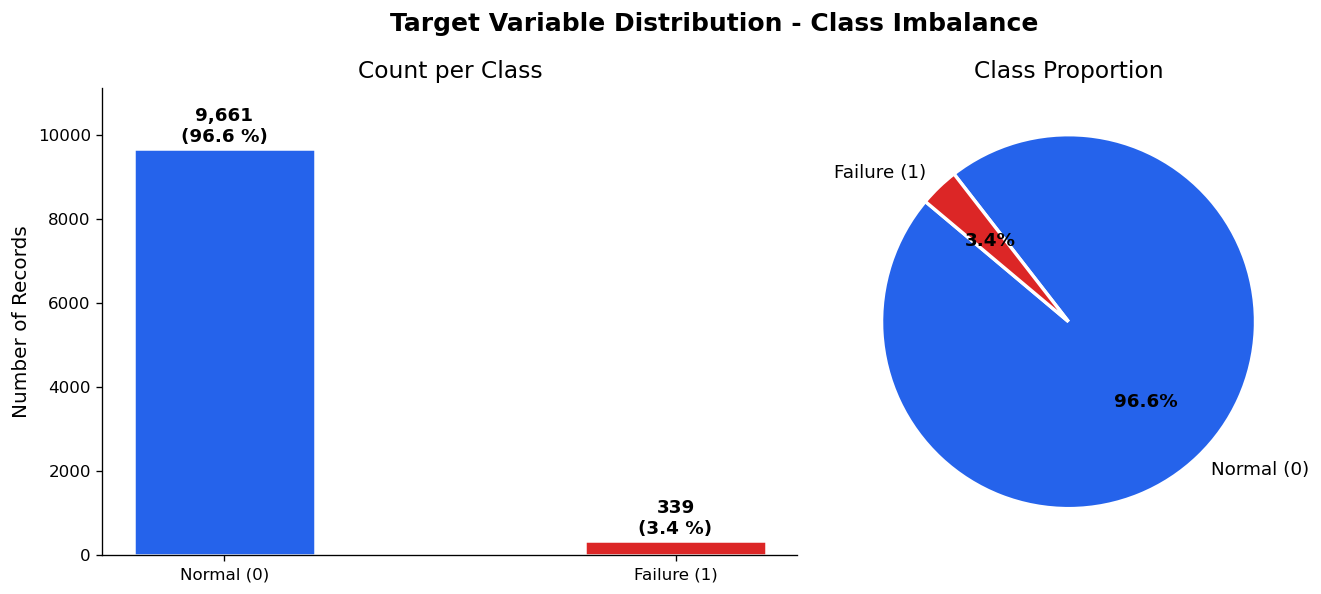


Imbalance Ration -> Normal: Failure = 9,661 : 339 (96.6% vs 3.4%)


In [6]:
# Target Distribution - Class Imbalance
counts = df['failure'].value_counts()
pct = df['failure'].value_counts(normalize = True) * 100
labels = ['Normal (0)', 'Failure (1)']
colors = [PALETTE['primary'], PALETTE['danger']]

fig, axes = plt.subplots(1, 2, figsize = (12, 5))
fig.suptitle("Target Variable Distribution - Class Imbalance", fontsize = 15, fontweight = 'bold')

# Bar Chart
axes[0].bar(labels, counts.values, color = colors, width = 0.4, edgecolor = 'white', linewidth = 1.5)
for i, (cnt, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, cnt + 80, f"{cnt:,}\n({p:.1f} %)", ha = 'center', va = 'bottom', fontsize = 11, fontweight = 'bold')

axes[0].set_title('Count per Class')
axes[0].set_ylabel('Number of Records')
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie Chart
wedges, texts, autotexts = axes[1].pie(counts.values, labels = labels, colors = colors, autopct = '%1.1f%%', startangle = 140, 
                                       wedgeprops = dict(edgecolor = 'white', linewidth = 2), textprops = dict(fontsize = 11))
for at in autotexts:
    at.set_fontweight('bold')

axes[1].set_title('Class Proportion')

plt.tight_layout()
save_fig('1_target_distribution.png')
plt.show()

print(f'\nImbalance Ration -> Normal: Failure = '
      f'{counts[0]:,} : {counts[1]:,} '
      f'({pct[0]:.1f}% vs {pct[1]:.1f}%)')

Figure saved -> ../outputs/figures/1_failure_type_breakdown.png


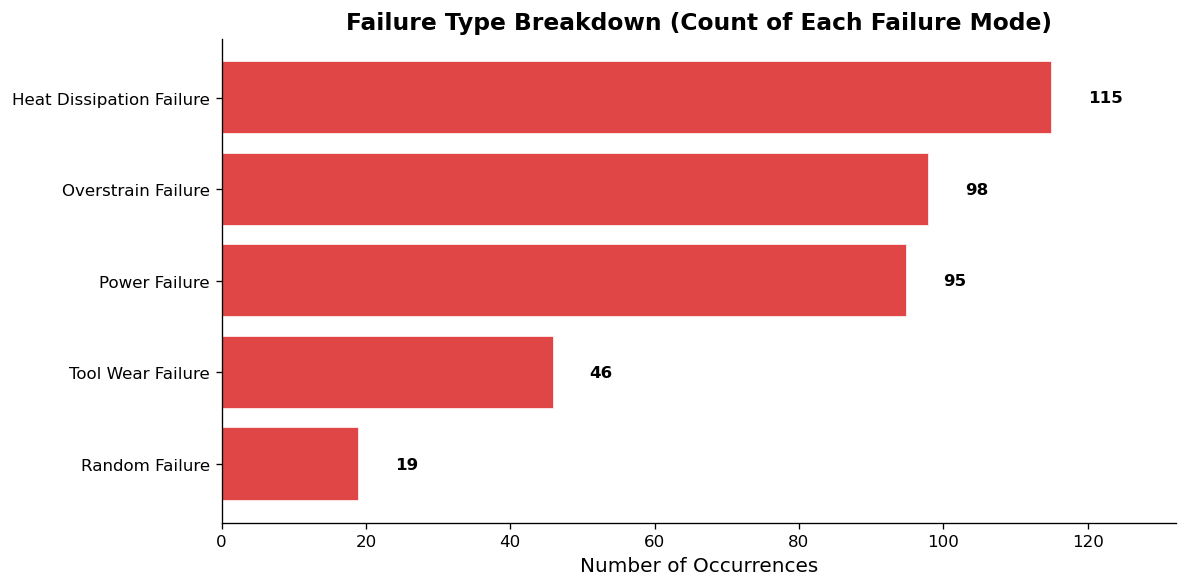

In [7]:
# Failure Type Breakdown
failure_cols = ['tool_wear_failure', 'heat_dissipation_failure', 'power_failure', 'overstrain_failure', 'random_failure']
failure_counts = df[failure_cols].sum().sort_values(ascending = True)

fig, ax = plt.subplots(figsize = (10, 5))
bars = ax.barh(failure_counts.index, failure_counts.values, color = PALETTE['danger'], edgecolor = 'white', linewidth = 1.2, alpha = 0.85)

for bar, val in zip(bars, failure_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2, f'{val:,}', va = 'center', fontsize = 10, fontweight = 'bold')

ax.set_title('Failure Type Breakdown (Count of Each Failure Mode)', fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Number of Occurrences')
ax.set_xlim(0, failure_counts.max() * 1.15)
ax.set_yticklabels([c.replace("_", " ").title() for c in failure_counts.index])
save_fig("1_failure_type_breakdown.png")
plt.show()

Figure saved -> ../outputs/figures/1_feature_distributions.png


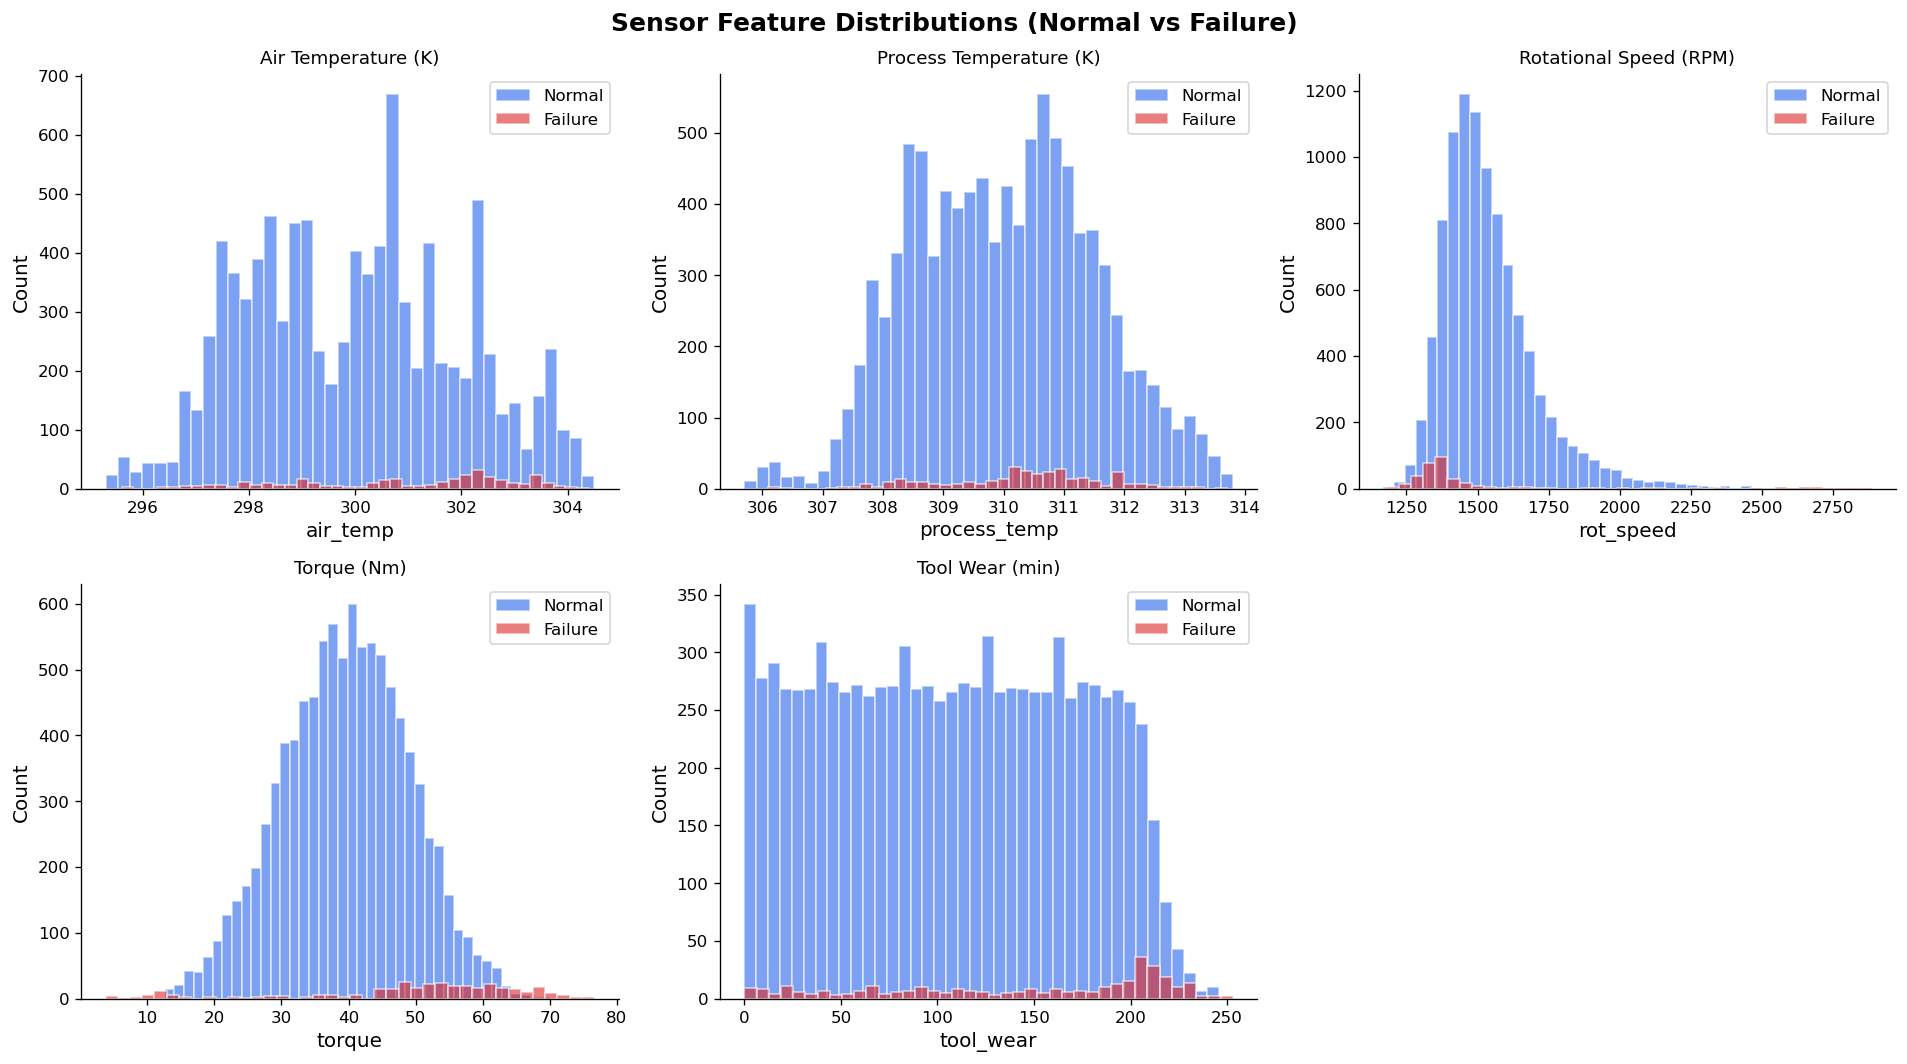

In [8]:
# Numerical Feature Distribution
num_features = ['air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear']
titles = ['Air Temperature (K)', 'Process Temperature (K)', 'Rotational Speed (RPM)', 'Torque (Nm)', 'Tool Wear (min)']

fig, axes = plt.subplots(2, 3, figsize = (16, 9))
fig.suptitle('Sensor Feature Distributions (Normal vs Failure)', fontsize = 15, fontweight = 'bold')
axes = axes.flatten()

for i, (feat, title) in enumerate(zip(num_features, titles)):
    for label, color, name in [(0, PALETTE['primary'], 'Normal'),
                               (1, PALETTE['danger'], 'Failure')]: axes[i].hist(df[df['failure'] == label][feat], bins = 40,
                                                                                alpha = 0.6, color = color, label = name, edgecolor = 'white')
        
    axes[i].set_title(title, fontsize = 11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend()

axes[-1].axis('off')  # hide the unused 6th subplot
plt.tight_layout()
save_fig('1_feature_distributions.png')
plt.show()

Figure saved -> ../outputs/figures/1_correlation_heatmap.png


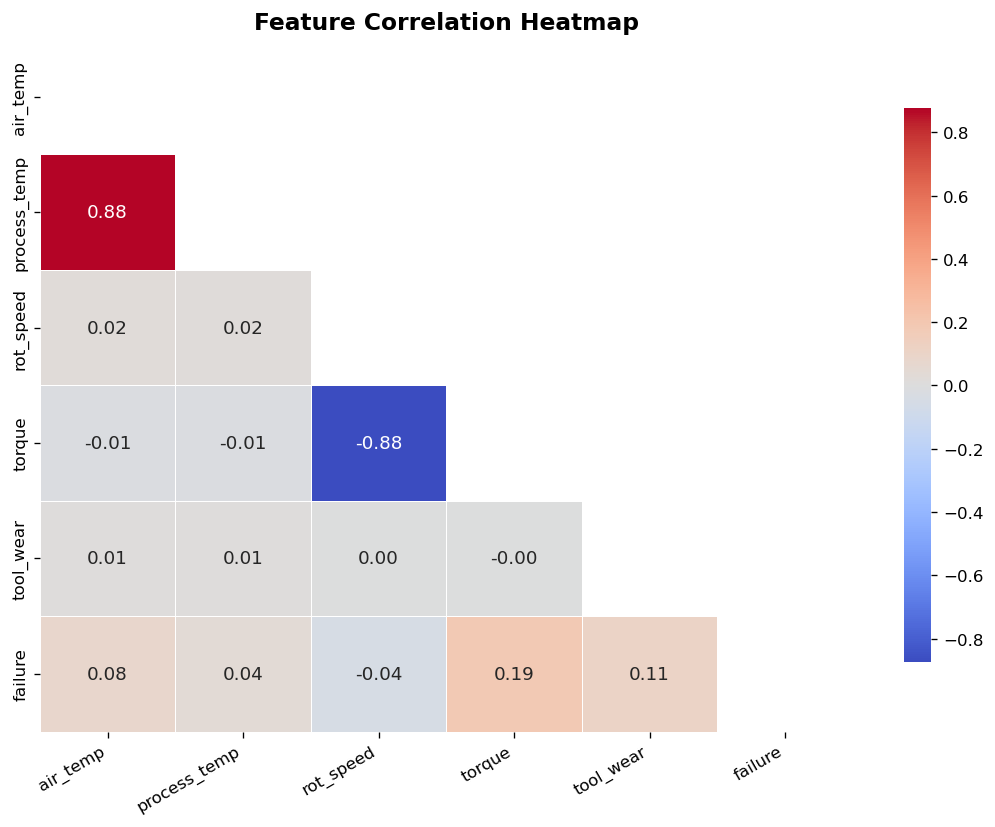

In [9]:
# Correlation Heatmap
corr_cols = num_features + ['failure']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize = (9, 7))
mask = np.triu(np.ones_like(corr, dtype = bool))  # show lower triangle only
sns.heatmap(corr, mask = mask, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0, linewidth = 0.5,
            annot_kws = {'size': 11}, ax = ax, cbar_kws = {'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize = 14, fontweight = 'bold')
plt.xticks(rotation = 30, ha = 'right')
save_fig('1_correlation_heatmap.png')
plt.show()

Figure saved -> ../outputs/figures/1_machine_type_analysis.png


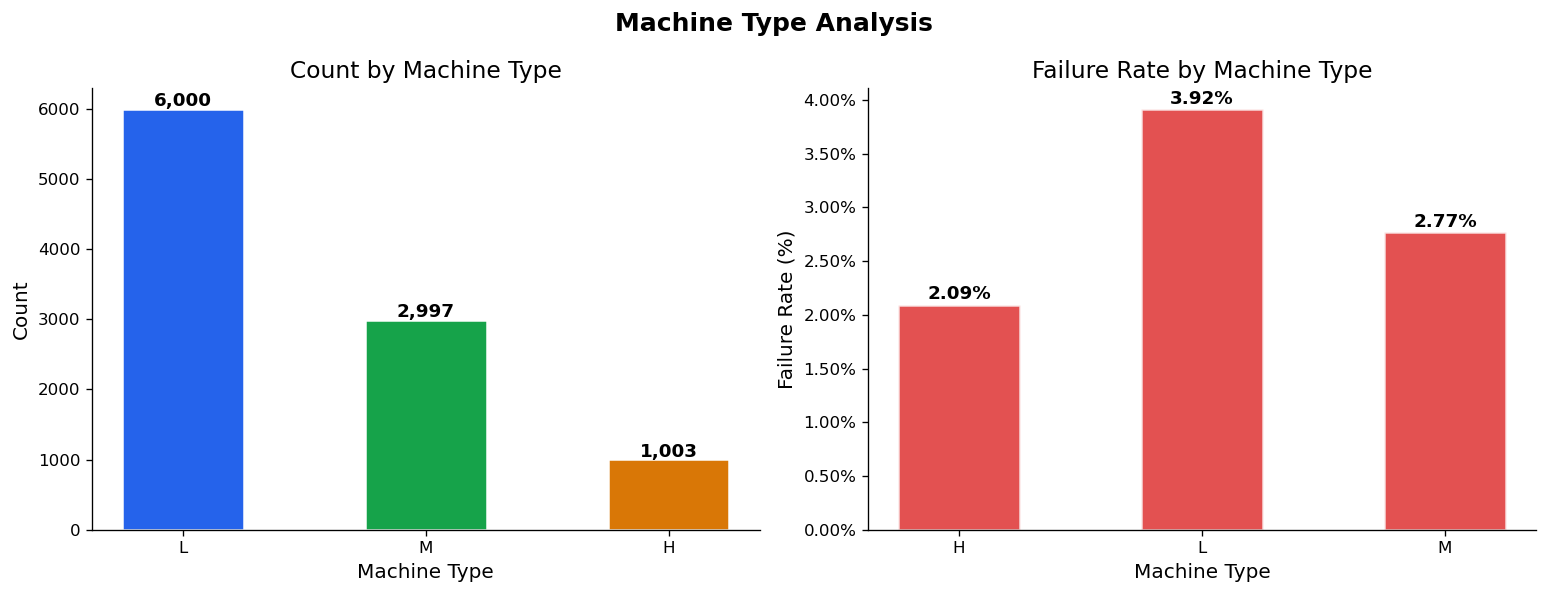

In [10]:
# Machine Tupe Distribution
type_counts = df['machine_type'].value_counts()
type_fail_rate = df.groupby('machine_type')['failure'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize = (13, 5))
fig.suptitle('Machine Type Analysis', fontsize = 15, fontweight = 'bold')

# Count per type
axes[0].bar(type_counts.index, type_counts.values, color = [PALETTE['primary'], PALETTE['success'], PALETTE['warning']],
            edgecolor = 'white', linewidth = 1.5, width = 0.5)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 40, f'{v:,}', ha = 'center', fontsize = 11, fontweight = 'bold')

axes[0].set_title('Count by Machine Type')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Machine Type')

# Failure rate per type
bars = axes[1].bar(type_fail_rate.index, type_fail_rate.values, color = PALETTE['danger'],
                   edgecolor = 'white', linewidth = 1.5, alpha = 0.8, width = 0.5)
for bar, val in zip(bars, type_fail_rate.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.05, f"{val:.2f}%",
                 ha = 'center', fontsize = 11, fontweight = 'bold')

axes[1].set_title('Failure Rate by Machine Type')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].set_xlabel('Machine Type')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
save_fig('1_machine_type_analysis.png')
plt.show()

In [11]:
# Section Summary
section_banner("Section 1 - Summary")
print(f'Total Records      : {len(df):,}')
print(f'Features Available : {df.shape[1] - 1}')
print(f'Normal Samples     : {counts[0]:,} ({pct[0]:.1f}%)')
print(f'Failure Samples    : {counts[1]:,} ({pct[1]:.1f}%)')
print(f'Imbalance Ratio    : ~{round(counts[0]/counts[1])}:1')
print(f'Missing Values     : None')


  Section 1 - Summary

Total Records      : 10,000
Features Available : 11
Normal Samples     : 9,661 (96.6%)
Failure Samples    : 339 (3.4%)
Imbalance Ratio    : ~28:1
Missing Values     : None


# Section 2: Preprocessing & Feature Engineering

In [12]:
# Copy Working DataFrame
# Always work on a copy so the raw df is preserved for reference
df2 = df.copy()
print(f'Working copy created. Shape: {df2.shape}')

Working copy created. Shape: (10000, 12)


In [15]:
# Encode Categorical Feature - machine_type
print('\nEncoding machine_type')
print(f"Unique values before encoding: {df2['machine_type'].unique()}")

le = LabelEncoder()
df2['machine_type_enc'] = le.fit_transform(df2['machine_type'])

# Show the mapping clearly
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f'Encoding map: {mapping}')
print(f"e.g. H -> {mapping['H']}  L -> {mapping['L']}  M -> {mapping['M']}")

# Save encoder for deployment use later
joblib.dump(le, os.path.join(MODELS_DIR, 'label_encoder.pkl'))
print("LabelEncoder saved -> outputs/models/label_encoder.pkl")


Encoding machine_type
Unique values before encoding: ['M' 'L' 'H']
Encoding map: {'H': 0, 'L': 1, 'M': 2}
e.g. H -> 0  L -> 1  M -> 2
LabelEncoder saved -> outputs/models/label_encoder.pkl
